In [1]:
# === SESSION BOOTSTRAP ===
from google.colab import drive
drive.mount('/content/drive')
import os, subprocess, sys
PARENT="/content/drive/MyDrive/UAV_TRUST_Research"; REPO=f"{PARENT}/uav-trust-research"
for fn in (".gitconfig",".git-credentials"):
    p=os.path.join(PARENT,fn)
    if os.path.exists(p): subprocess.run(f'cp "{p}" /root/{fn}',shell=True)
subprocess.run("git config --global credential.helper store",shell=True)
if os.path.isdir(REPO):
    os.chdir(REPO); sys.path.insert(0,REPO) if REPO not in sys.path else None; print("cwd:",os.getcwd())
else: print("run 00_setup first")

Mounted at /content/drive
cwd: /content/drive/MyDrive/UAV_TRUST_Research/uav-trust-research


In [2]:
!pip install xgboost shap scikit-learn matplotlib pandas numpy scipy pyarrow requests --quiet

In [3]:
# Generalization across model families: Random Forest (bagging) and MLP (non-tree) vs XGBoost.
DATASETS=[
 {"name":"UAVIDS-2025","kind":"zenodo","record":"15336998","data_dir":"data/uavids2025",
  "label_col":"label","normal_value":"Normal Traffic","include_families":None,"subsample_n":None,
  "drops":["unnamed","flowid","srcaddr","dstaddr","srcport","dstport","index","timestamp"]},
 {"name":"UAV-NIDD","kind":"file","file":"data/uav_nidd/UAV-NDD CSV/UAV-Case1-Label.csv",
  "parquet":"data/uav_nidd/case1.parquet","data_dir":"data/uav_nidd","label_col":"Label",
  "normal_value":"Normal","include_families":["DDoS","UDP Flooding","MITM","Jamming","BruteForce","De-authentication"],
  "subsample_n":200000,
  "drops":["unnamed","index","ip.src","ip.dst","ip.proto","wlan.tag","srcport","dstport","udp.srcport","udp.dstport",
           "frame.time","frame.number","time_epoch","time_relative","time_delta","bssid","mactime",
           "vendor_oui","wlan_radio.timestamp","wlan_radio.start_tsf","radiotap.timestamp","wlan.seq"]},
]
CFG={"seeds":list(range(5)),"alpha":0.10,"nbins":15,"n_shap":800,
     "normal_fracs":{"train":0.60,"cal":0.20,"test_seen":0.10,"test_shift":0.10},
     "family_fracs":{"train":0.60,"cal":0.20,"test_seen":0.20},
     "fig_dir":"figures","report_dir":"reports"}
MODELS=["RandomForest","MLP"]
for d in [CFG["fig_dir"],CFG["report_dir"]]: os.makedirs(d,exist_ok=True)
print("configured")

configured


In [4]:
import numpy as np, pandas as pd, requests, glob, zipfile, importlib, gc, src.data
importlib.reload(src.data)
import matplotlib.pyplot as plt, shap
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score
from src.data import load_csvs, detect_schema, prepare_splits
from src.trust import top_label_ece, conformal_qhat

def load_dataset(spec):
    dd=spec["data_dir"]; os.makedirs(dd,exist_ok=True)
    if spec["kind"]=="zenodo":
        if not glob.glob(dd+"/**/*.csv",recursive=True):
            meta=requests.get(f"https://zenodo.org/api/records/{spec['record']}",timeout=60).json()
            for f in meta.get("files",[]):
                n,u=f["key"],f["links"]["self"]
                if n.lower().endswith((".csv",".zip",".gz")): open(os.path.join(dd,n),"wb").write(requests.get(u,timeout=1200).content)
            for z in glob.glob(dd+"/*.zip"): zipfile.ZipFile(z).extractall(dd)
        df=load_csvs(dd); lc,nv,fams=detect_schema(df,spec["label_col"],spec["normal_value"])
    else:
        pq=spec.get("parquet")
        df=pd.read_parquet(pq) if pq and os.path.exists(pq) else pd.read_csv(spec["file"],low_memory=False,encoding="latin-1")
        lc,nv=spec["label_col"],spec["normal_value"]; fams=[v for v in df[lc].unique() if v!=nv]
    if spec.get("subsample_n") and len(df)>spec["subsample_n"]:
        df=df.groupby(lc,group_keys=False).sample(frac=spec["subsample_n"]/len(df),random_state=42).reset_index(drop=True)
    if spec.get("include_families"):
        df=df[df[lc].isin([nv]+list(spec["include_families"]))].reset_index(drop=True); fams=list(spec["include_families"])
    return df,lc,nv,fams

def build_clf(name,seed):
    if name=="RandomForest": return RandomForestClassifier(n_estimators=200,max_depth=20,n_jobs=-1,random_state=seed)
    if name=="MLP": return MLPClassifier(hidden_layer_sizes=(128,64),max_iter=80,early_stopping=True,random_state=seed)
def cov_detail(p,y,qhat):
    p=np.asarray(p); y=np.asarray(y); in_a=(1-p)<=qhat; in_n=p<=qhat
    inset=np.where(y==1,in_a,in_n)
    return float(inset.mean()), float(np.mean([inset[y==k].mean() for k in np.unique(y)]))
def mean_shap_rf(ex,X):
    sv=ex.shap_values(X)
    if isinstance(sv,list): sv=sv[1]
    sv=np.asarray(sv)
    if sv.ndim==3: sv=sv[...,1]
    return sv.mean(0)
print("helpers ready")

helpers ready


In [5]:
# PANEL: trust metrics for RandomForest and MLP across families/seeds
rows=[]; loaded={}
for spec in DATASETS:
    df,lc,nv,fams=load_dataset(spec); loaded[spec["name"]]=(df,lc,nv,fams)
    print(spec["name"],"loaded",len(df))
    for model in MODELS:
        for F in fams:
            for seed in CFG["seeds"]:
                S=prepare_splits(df,lc,nv,F,spec["drops"],CFG["normal_fracs"],CFG["family_fracs"],seed)
                for k in ["X_train","X_cal","X_seen","X_shift"]: S[k]=S[k].astype(np.float32)
                clf=build_clf(model,seed).fit(S["X_train"],S["y_train"])
                p_cal=clf.predict_proba(S["X_cal"])[:,1]; p_sh=clf.predict_proba(S["X_shift"])[:,1]; p_se=clf.predict_proba(S["X_seen"])[:,1]
                qhat=conformal_qhat(p_cal,S["y_cal"],alpha=CFG["alpha"])
                m_sh,b_sh=cov_detail(p_sh,S["y_shift"],qhat); m_se,_=cov_detail(p_se,S["y_seen"],qhat)
                rows.append({"model":model,"dataset":spec["name"],"held_out":str(F),"seed":seed,
                    "shift_balacc":balanced_accuracy_score(S["y_shift"],(p_sh>=.5).astype(int)),
                    "shift_ECE":top_label_ece(p_sh,S["y_shift"],CFG["nbins"]),
                    "shift_cov_marg":m_sh,"shift_cov_bal":b_sh,"seen_cov_marg":m_se})
                del S,clf; gc.collect()
            print(" ",model,spec["name"],F,"done")
    del df; gc.collect()
P=pd.DataFrame(rows); P.to_csv(os.path.join(CFG["report_dir"],"12_second_clf_panel.csv"),index=False)
print("rows:",len(P))

UAVIDS-2025 loaded 122171
  RandomForest UAVIDS-2025 Sybil Attack done
  RandomForest UAVIDS-2025 Blackhole Attack done
  RandomForest UAVIDS-2025 Wormhole Attack done
  RandomForest UAVIDS-2025 Flooding Attack done
  MLP UAVIDS-2025 Sybil Attack done
  MLP UAVIDS-2025 Blackhole Attack done
  MLP UAVIDS-2025 Wormhole Attack done
  MLP UAVIDS-2025 Flooding Attack done
UAV-NIDD loaded 168881
  RandomForest UAV-NIDD DDoS done
  RandomForest UAV-NIDD UDP Flooding done
  RandomForest UAV-NIDD MITM done
  RandomForest UAV-NIDD Jamming done
  RandomForest UAV-NIDD BruteForce done
  RandomForest UAV-NIDD De-authentication done
  MLP UAV-NIDD DDoS done
  MLP UAV-NIDD UDP Flooding done
  MLP UAV-NIDD MITM done
  MLP UAV-NIDD Jamming done
  MLP UAV-NIDD BruteForce done
  MLP UAV-NIDD De-authentication done
rows: 100


In [6]:
# TABLE: marginal coverage per family across the three model families (XGBoost from nb10)
try:
    xgb_p=pd.read_csv("reports/10_unified_panel_raw.csv").groupby(["dataset","held_out"])["shift_cov_marg"].mean()
except Exception: xgb_p=None
rf=P[P.model=="RandomForest"].groupby(["dataset","held_out"])["shift_cov_marg"].mean()
mlp=P[P.model=="MLP"].groupby(["dataset","held_out"])["shift_cov_marg"].mean()
comp=pd.DataFrame({"XGBoost":xgb_p,"RandomForest":rf,"MLP":mlp}).round(3)
print("Marginal coverage on the shifted family, by model (target 0.90):")
print(comp.to_string()); comp.to_csv(os.path.join(CFG["report_dir"],"12_coverage_by_model.csv"))
print("\nFamilies with marginal coverage < 0.80 (coverage collapse), by model:")
for col in comp.columns:
    if comp[col].notna().any(): print(f"  {col}: {(comp[col]<0.80).sum()} of {comp[col].notna().sum()}")

Marginal coverage on the shifted family, by model (target 0.90):
                               XGBoost  RandomForest    MLP
dataset     held_out                                       
UAV-NIDD    BruteForce           0.656         0.570  0.987
            DDoS                 0.065         0.336  0.000
            De-authentication    0.285         0.362  0.890
            Jamming              0.001         0.038  0.974
            MITM                 0.151         0.889  0.106
            UDP Flooding         0.802         0.776  0.988
UAVIDS-2025 Blackhole Attack     0.408         0.357  0.498
            Flooding Attack      0.718         0.550  0.967
            Sybil Attack         0.912         0.935  0.971
            Wormhole Attack      0.635         0.539  0.651

Families with marginal coverage < 0.80 (coverage collapse), by model:
  XGBoost: 8 of 10
  RandomForest: 8 of 10
  MLP: 4 of 10


In [7]:
# Does the coverage-collapse RANKING agree across models? (Spearman on per-family coverage)
print("Rank agreement of per-family coverage across model families:")
for a in comp.columns:
    for b in comp.columns:
        if a<b and comp[a].notna().all() and comp[b].notna().all():
            print(f"  Spearman({a}, {b}) = {spearmanr(comp[a],comp[b]).correlation:.3f}")

Rank agreement of per-family coverage across model families:
  Spearman(RandomForest, XGBoost) = 0.721
  Spearman(MLP, XGBoost) = 0.527
  Spearman(MLP, RandomForest) = 0.285


In [8]:
# MECHANISM generalization: fragility (SHAP reversal) predicts coverage for Random Forest too
frag=[]
for spec in DATASETS:
    df,lc,nv,fams=loaded[spec["name"]]
    for F in fams:
        vals=[]
        for seed in CFG["seeds"][:3]:
            S=prepare_splits(df,lc,nv,F,spec["drops"],CFG["normal_fracs"],CFG["family_fracs"],seed)
            for k in ["X_train","X_seen","X_shift"]: S[k]=S[k].astype(np.float32)
            seen=[g for g in fams if g!=F]
            rf=RandomForestClassifier(n_estimators=150,max_depth=18,n_jobs=-1,random_state=seed).fit(S["X_train"],S["y_train"])
            ex=shap.TreeExplainer(rf)
            def smp(X,m,sd):
                idx=np.where(m)[0]
                if len(idx)>CFG["n_shap"]: idx=np.random.default_rng(sd).choice(idx,CFG["n_shap"],replace=False)
                return X[idx]
            m_ref=mean_shap_rf(ex,smp(S["X_seen"],np.isin(S["fam_seen"],seen),seed))
            m_held=mean_shap_rf(ex,smp(S["X_shift"],S["fam_shift"]==F,seed))
            rv=np.maximum(m_ref,0.0)*np.maximum(-m_held,0.0); vals.append(float(rv.sum()))
            del S,rf,ex; gc.collect()
        frag.append({"dataset":spec["name"],"held_out":str(F),"frag_rf":round(np.mean(vals),3)})
    del df; gc.collect()
fr=pd.DataFrame(frag)
fr=fr.merge(rf if False else comp["RandomForest"].reset_index(),on=["dataset","held_out"])
fr.to_csv(os.path.join(CFG["report_dir"],"12_rf_fragility.csv"),index=False)
print(fr.to_string(index=False))
for ds in fr["dataset"].unique():
    sub=fr[fr["dataset"]==ds]
    if len(sub)>2: print(f"{ds}: Spearman(RF fragility, RF coverage) = {spearmanr(sub['frag_rf'],sub['RandomForest']).correlation:.3f}")

    dataset          held_out  frag_rf  RandomForest
UAVIDS-2025      Sybil Attack    0.006         0.935
UAVIDS-2025  Blackhole Attack    0.018         0.357
UAVIDS-2025   Wormhole Attack    0.003         0.539
UAVIDS-2025   Flooding Attack    0.005         0.550
   UAV-NIDD              DDoS    0.000         0.336
   UAV-NIDD      UDP Flooding    0.000         0.776
   UAV-NIDD              MITM    0.000         0.889
   UAV-NIDD           Jamming    0.000         0.038
   UAV-NIDD        BruteForce    0.000         0.570
   UAV-NIDD De-authentication    0.000         0.362
UAVIDS-2025: Spearman(RF fragility, RF coverage) = -0.200
UAV-NIDD: Spearman(RF fragility, RF coverage) = nan


/tmp/ipykernel_601/3214819222.py:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  if len(sub)>2: print(f"{ds}: Spearman(RF fragility, RF coverage) = {spearmanr(sub['frag_rf'],sub['RandomForest']).correlation:.3f}")


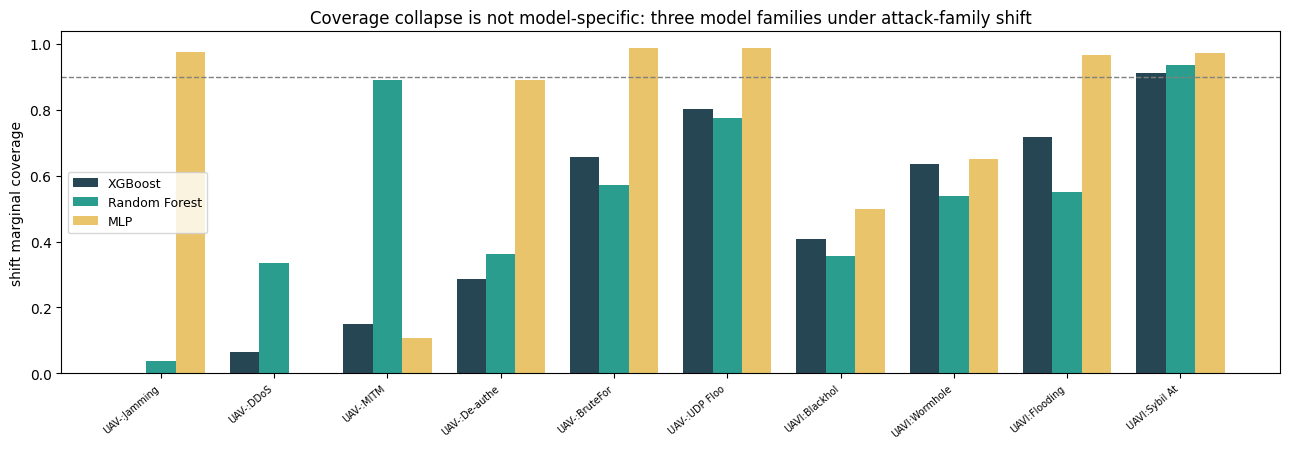

In [9]:
# FIGURE: marginal coverage per family, three model families side by side
order=comp.reset_index().sort_values(["dataset","XGBoost"])
labels=[f"{r.dataset[:4]}:{r.held_out[:8]}" for r in order.itertuples()]
x=np.arange(len(order)); w=0.26
fig,ax=plt.subplots(figsize=(13,4.6))
ax.bar(x-w,order["XGBoost"],w,label="XGBoost",color="#264653")
ax.bar(x,order["RandomForest"],w,label="Random Forest",color="#2a9d8f")
ax.bar(x+w,order["MLP"],w,label="MLP",color="#e9c46a")
ax.axhline(0.90,ls="--",color="gray",lw=1)
ax.set_xticks(x); ax.set_xticklabels(labels,rotation=40,ha="right",fontsize=7)
ax.set_ylabel("shift marginal coverage"); ax.set_title("Coverage collapse is not model-specific: three model families under attack-family shift")
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(os.path.join(CFG["fig_dir"],"12_model_generalization.png"),dpi=150,bbox_inches="tight"); plt.show()

In [ ]:
# Commit
!git add reports/ figures/ notebooks/
!git commit -m "12 model generalization: coverage-sensitivity + fragility mechanism reproduced on Random Forest and MLP (not XGBoost-specific)"
!git push origin main